#  Customer Churn Prediction
**End-to-end ML pipeline: EDA → Training → Calibration → SHAP → Business Impact**

> Dataset: IBM Telco Customer Churn  
> Target: `Churn` (binary — Yes / No)


## 0. Setup & Imports

In [1]:
!pip install -q optuna shap imbalanced-learn xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.8 MB/s eta 0:00:00


In [2]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Evaluation
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# Explainability
import shap

import warnings
warnings.filterwarnings("ignore")

SEED = 42
print("All imports successful")

All imports successful


## 1. Data Loading & First Look

In [6]:
df_raw=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df_raw.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


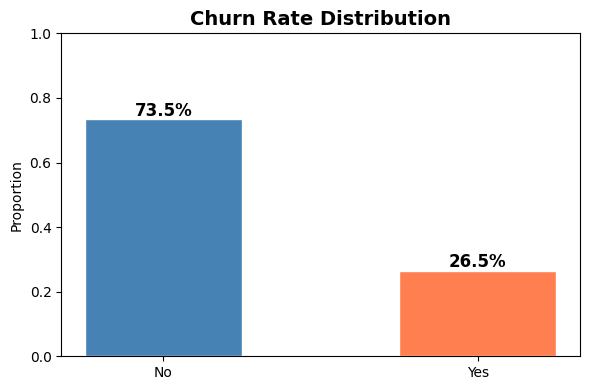

Churn: 26.5% | Retained: 73.5%
Class imbalance detected — will handle with SMOTE / class_weight


In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts = df_raw["Churn"].value_counts(normalize=True)
bars = ax.bar(churn_counts.index, churn_counts.values, color=["steelblue", "coral"], edgecolor="white", width=0.5)
for bar, val in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.1%}", ha="center", fontsize=12, fontweight="bold")
ax.set_title("Churn Rate Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Proportion"); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()
print(f"Churn: {churn_counts.get('Yes',0):.1%} | Retained: {churn_counts.get('No',0):.1%}")
print("Class imbalance detected — will handle with SMOTE / class_weight")

## 2. Preprocessing & Feature Engineering

In [10]:
df = df_raw.copy()

# Fix data types
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
print(f"Rows after dropna: {len(df)}")

# Drop uninformative columns
df.drop(columns=["customerID"], inplace=True)

# Encode target
df["Churn"] = (df["Churn"] == "Yes").astype(int)
print(f"Churn positives: {df['Churn'].sum()} / {len(df)}")

# Encode categoricals
binary_cols = [c for c in df.select_dtypes("object") if df[c].nunique() == 2]
multi_cols  = [c for c in df.select_dtypes("object") if df[c].nunique() > 2]
print(f"Binary cols: {binary_cols}")
print(f"Multi-class cols: {multi_cols}")

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Feature engineering
df["charges_per_month"] = df["TotalCharges"] / (df["tenure"] + 1)
df["long_term"]         = (df["tenure"] > 24).astype(int)
print(f"Final features: {df.shape[1] - 1} | Samples: {len(df)}")

# Train / test split
X = df.drop(columns=["Churn"])
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Rows after dropna: 7032
Churn positives: 1869 / 7032
Binary cols: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-class cols: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Final features: 32 | Samples: 7032
Train: (5625, 32) | Test: (1407, 32)


## 3. Exploratory Data Analysis

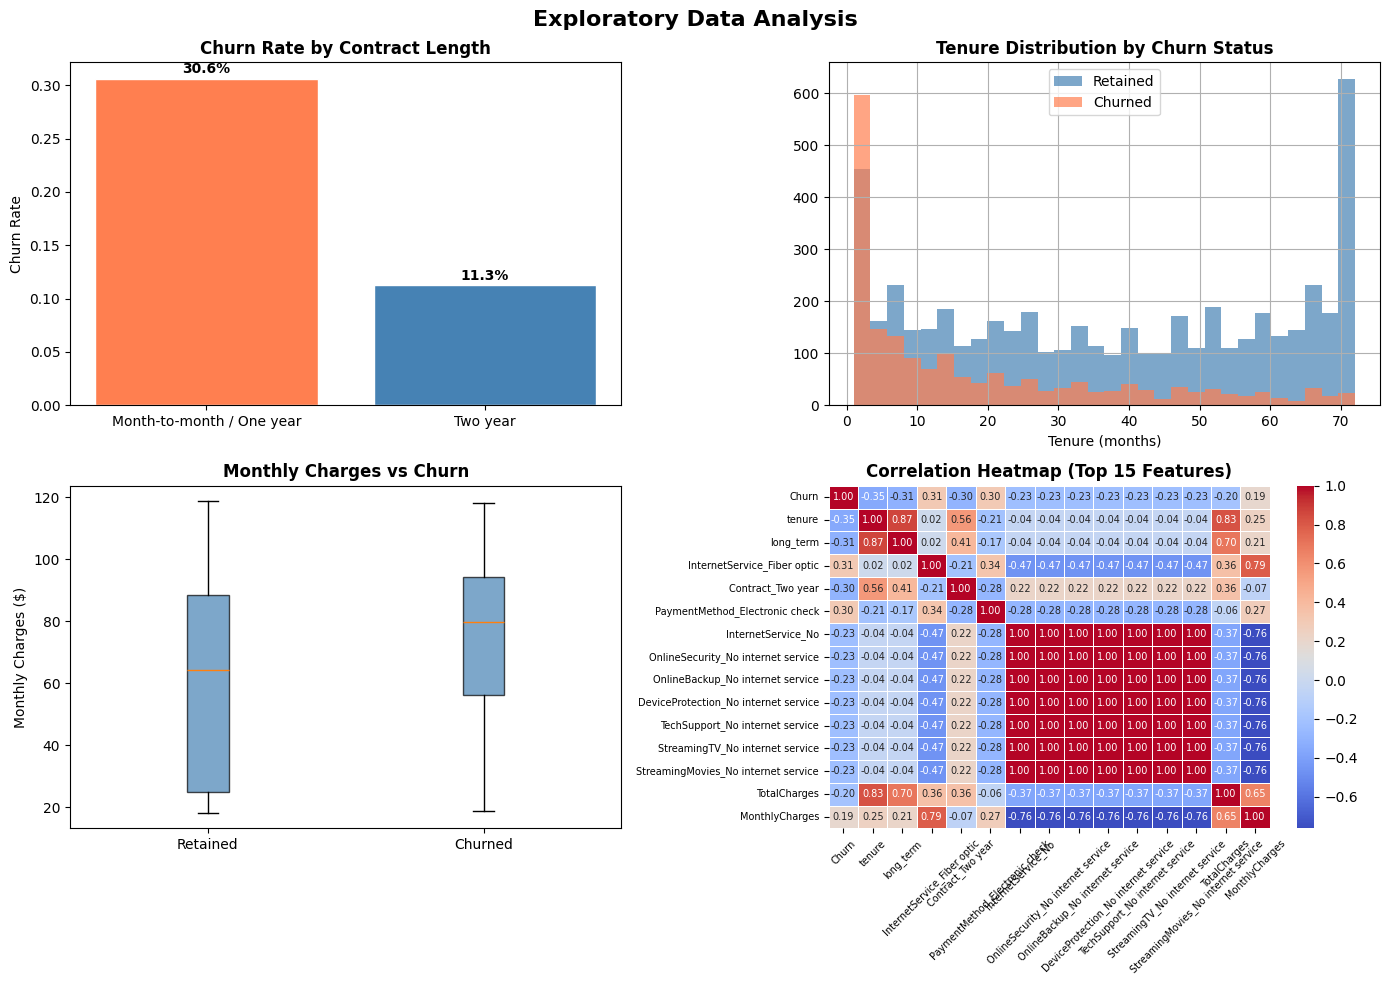

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Churn rate by contract type
contract_cols = [c for c in df.columns if "Contract" in c]
if contract_cols:
    contract_churn = df.groupby(contract_cols[0])["Churn"].mean()
    labels = ["Month-to-month / One year", "Two year"]
    axes[0,0].bar(labels, contract_churn.values, color=["coral","steelblue"], edgecolor="white")
    axes[0,0].set_title("Churn Rate by Contract Length", fontweight="bold")
    axes[0,0].set_ylabel("Churn Rate")
    for i, v in enumerate(contract_churn.values):
        axes[0,0].text(i, v + 0.005, f"{v:.1%}", ha="center", fontweight="bold")

# Tenure distribution
df[df["Churn"]==0]["tenure"].hist(ax=axes[0,1], bins=30, alpha=0.7, color="steelblue", label="Retained")
df[df["Churn"]==1]["tenure"].hist(ax=axes[0,1], bins=30, alpha=0.7, color="coral", label="Churned")
axes[0,1].set_title("Tenure Distribution by Churn Status", fontweight="bold")
axes[0,1].set_xlabel("Tenure (months)"); axes[0,1].legend()

# Monthly charges boxplot
axes[1,0].boxplot(
    [df[df["Churn"]==0]["MonthlyCharges"], df[df["Churn"]==1]["MonthlyCharges"]],
    labels=["Retained","Churned"], patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.7)
)
axes[1,0].set_title("Monthly Charges vs Churn", fontweight="bold")
axes[1,0].set_ylabel("Monthly Charges ($)")

# Correlation heatmap
top_features = df.corr()["Churn"].abs().nlargest(15).index
sns.heatmap(df[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[1,1], linewidths=0.5, annot_kws={"size":7})
axes[1,1].set_title("Correlation Heatmap (Top 15 Features)", fontweight="bold")
axes[1,1].tick_params(axis="x", rotation=45, labelsize=7)
axes[1,1].tick_params(axis="y", rotation=0, labelsize=7)

plt.suptitle("Exploratory Data Analysis", fontsize=16, fontweight="bold")
plt.tight_layout(); plt.show()

## 4. Handling Class Imbalance (SMOTE)

Train churn rate (before SMOTE): 0.266
  Class 0 (No churn): 4130
  Class 1 (Churn):    1495

After SMOTE:
Churn
0    4130
1    4130


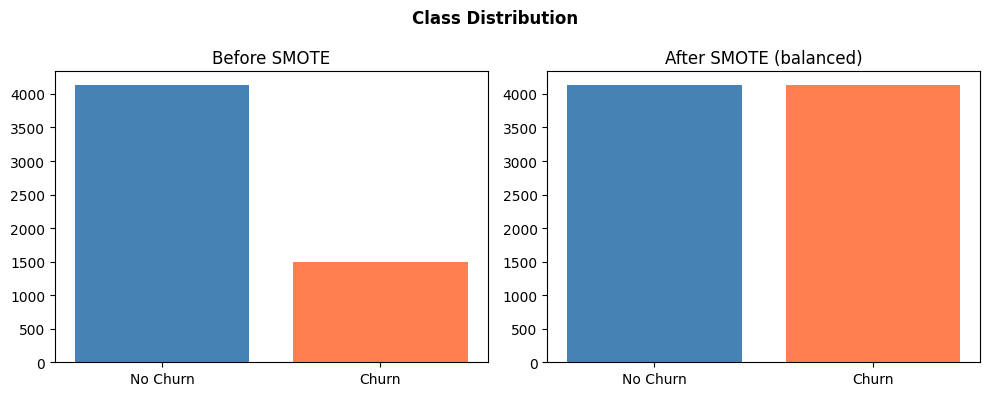

Note: For tree models we use class_weight='balanced' instead of SMOTE.


In [13]:
print(f"Train churn rate (before SMOTE): {y_train.mean():.3f}")
print(f"  Class 0 (No churn): {(y_train==0).sum()}")
print(f"  Class 1 (Churn):    {(y_train==1).sum()}")

smote = SMOTE(random_state=SEED)
X_res, y_res = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE:")
print(pd.Series(y_res).value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["No Churn","Churn"], [(y_train==0).sum(),(y_train==1).sum()], color=["steelblue","coral"])
axes[0].set_title("Before SMOTE")
axes[1].bar(["No Churn","Churn"], [(y_res==0).sum(),(y_res==1).sum()], color=["steelblue","coral"])
axes[1].set_title("After SMOTE (balanced)")
plt.suptitle("Class Distribution", fontweight="bold")
plt.tight_layout(); plt.show()
print("Note: For tree models we use class_weight='balanced' instead of SMOTE.")

## 5. Model Training & Comparison

Cross-validation ROC-AUC (5-fold):
---------------------------------------------
Logistic Regression      : 0.8490 +/- 0.0048
Random Forest            : 0.8317 +/- 0.0078
XGBoost                  : 0.8259 +/- 0.0059


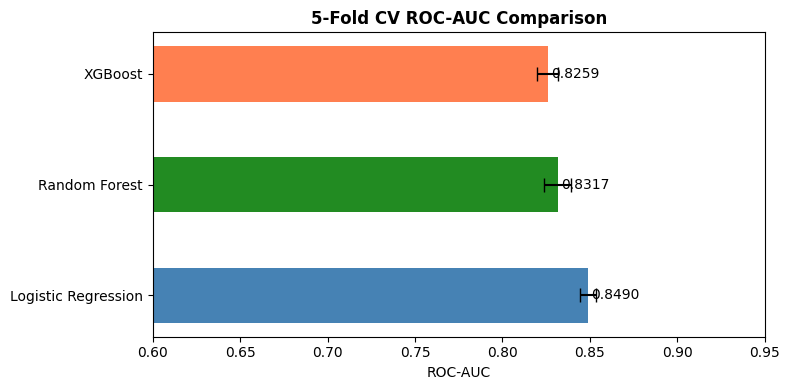

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "Random Forest":       RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=SEED),
    "XGBoost":             XGBClassifier(
                               scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                               use_label_encoder=False, eval_metric="logloss", random_state=SEED),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

print("Cross-validation ROC-AUC (5-fold):")
print("-" * 45)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    results[name] = scores
    print(f"{name:25s}: {scores.mean():.4f} +/- {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds  = [results[n].std()  for n in names]
bars  = ax.barh(names, means, xerr=stds, color=["steelblue","forestgreen","coral"], height=0.5, capsize=5)
for bar, val in zip(bars, means):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center", fontsize=10)
ax.set_xlabel("ROC-AUC"); ax.set_xlim(0.6, 0.95)
ax.set_title("5-Fold CV ROC-AUC Comparison", fontweight="bold")
plt.tight_layout(); plt.show()

In [15]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Fitted: {name}")

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    print(classification_report(y_test, y_pred, target_names=["No Churn","Churn"]))
    print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
    print(f"  PR-AUC  : {average_precision_score(y_test, y_proba):.4f}")

Fitted: Logistic Regression
Fitted: Random Forest
Fitted: XGBoost

  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1033
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

  ROC-AUC : 0.8391
  PR-AUC  : 0.6579

  Random Forest
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1033
       Churn       0.65      0.51      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

  ROC-AUC : 0.8216
  PR-AUC  : 0.6158

  XGBoost
              precision    recall  f1-score   support

    No Churn       0.87      0.77      0.82      1033
       Churn       0.52      0.68      0.59 

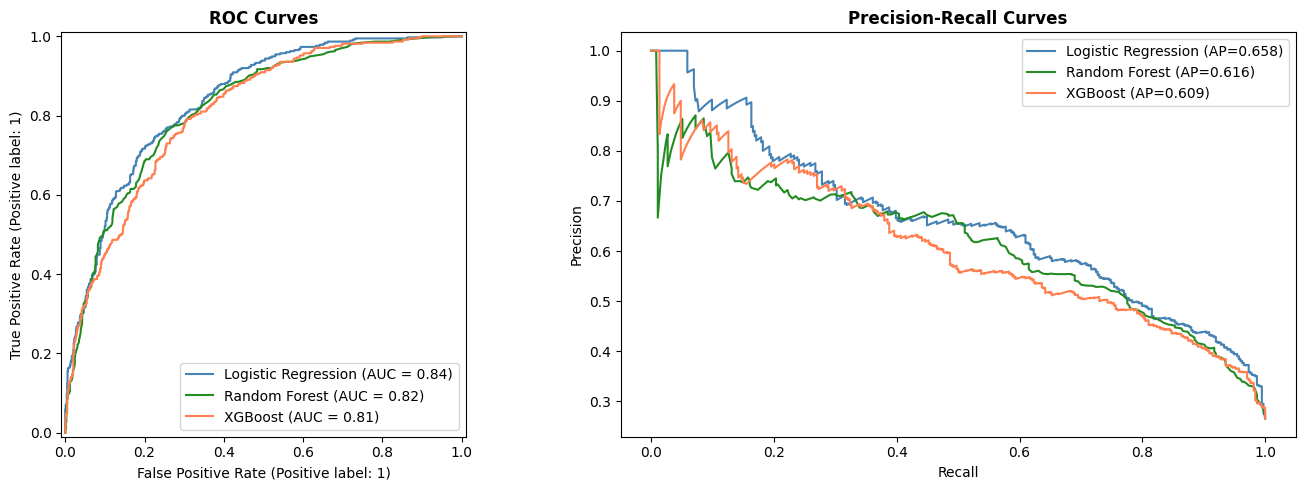

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["steelblue","forestgreen","coral"]
for (name, model), color in zip(models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name=name, color=color)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=color)

axes[0].set_title("ROC Curves", fontweight="bold")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves", fontweight="bold"); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Hyperparameter Tuning with Optuna

In [17]:
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
        "max_depth":         trial.suggest_int("max_depth", 3, 9),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight":  (y_train==0).sum() / (y_train==1).sum(),
        "use_label_encoder": False,
        "eval_metric":       "logloss",
        "random_state":      SEED,
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best ROC-AUC: {study.best_value:.4f}")
print(f"Best params : {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]

Best ROC-AUC: 0.8495
Best params : {'n_estimators': 357, 'max_depth': 4, 'learning_rate': 0.02098913431989378, 'subsample': 0.6811821509376955, 'colsample_bytree': 0.6211798289180938}


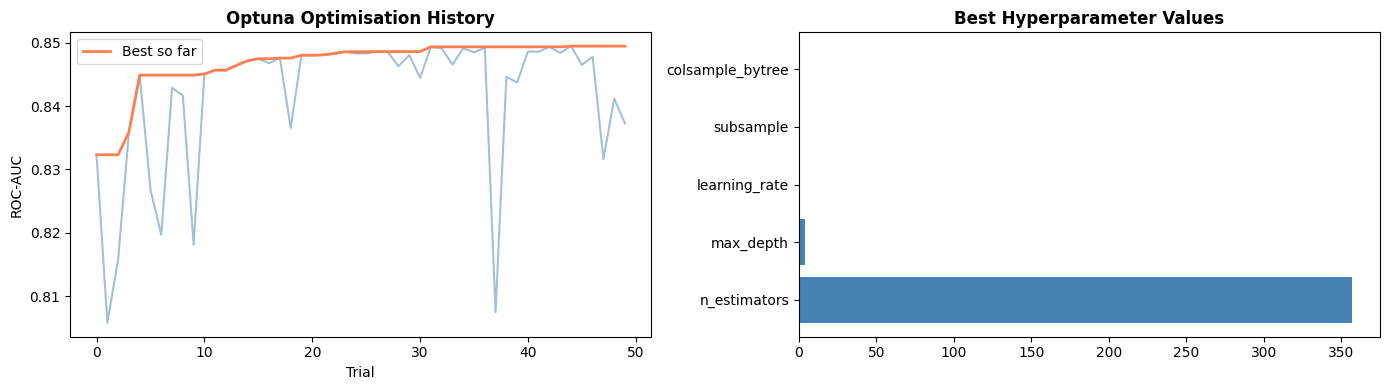

Best XGBoost fitted on full training set


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
trial_vals = [t.value for t in study.trials]
axes[0].plot(trial_vals, alpha=0.5, color="steelblue")
axes[0].plot(np.maximum.accumulate(trial_vals), color="coral", linewidth=2, label="Best so far")
axes[0].set_title("Optuna Optimisation History", fontweight="bold")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("ROC-AUC"); axes[0].legend()

param_names = list(study.best_params.keys())
param_vals  = [study.best_params[p] if isinstance(study.best_params[p], float) else float(study.best_params[p])
               for p in param_names]
axes[1].barh(param_names, param_vals, color="steelblue")
axes[1].set_title("Best Hyperparameter Values", fontweight="bold")
plt.tight_layout(); plt.show()

best_xgb = XGBClassifier(**study.best_params, use_label_encoder=False, eval_metric="logloss", random_state=SEED)
best_xgb.fit(X_train, y_train)
print("Best XGBoost fitted on full training set")

## 7. Probability Calibration

Calibrated model fitted


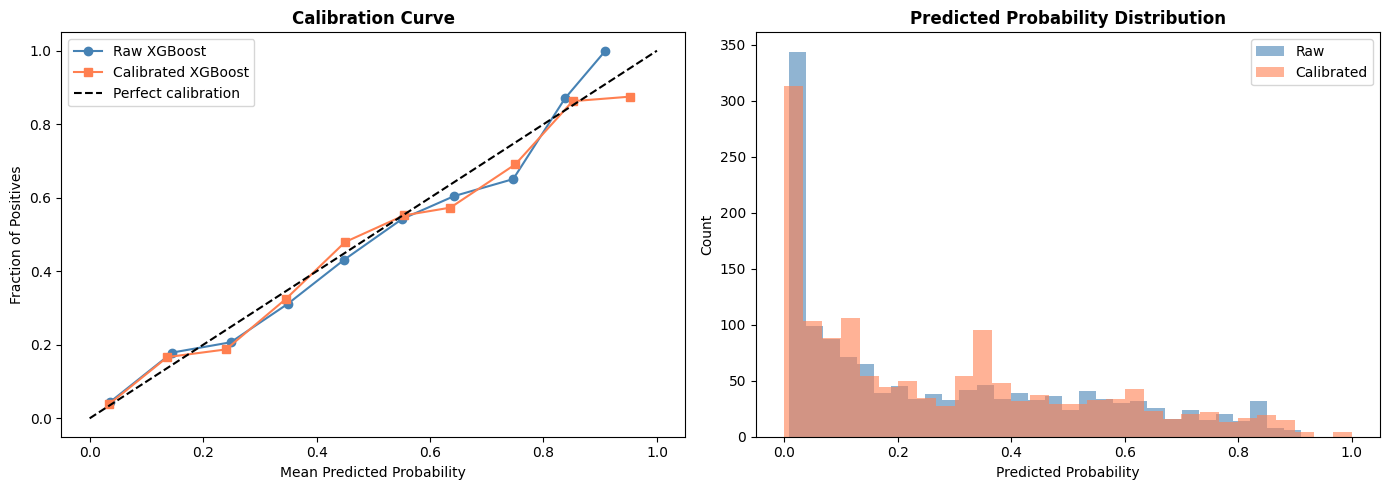

ROC-AUC raw:        0.8389
ROC-AUC calibrated: 0.8403


In [19]:
calibrated_model = CalibratedClassifierCV(best_xgb, method="isotonic", cv=5)
calibrated_model.fit(X_train, y_train)
print("Calibrated model fitted")

y_proba_raw = best_xgb.predict_proba(X_test)[:, 1]
y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]

prob_true_raw, prob_pred_raw = calibration_curve(y_test, y_proba_raw, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(prob_pred_raw, prob_true_raw, marker="o", color="steelblue", label="Raw XGBoost")
axes[0].plot(prob_pred_cal, prob_true_cal, marker="s", color="coral",     label="Calibrated XGBoost")
axes[0].plot([0,1],[0,1],"k--", label="Perfect calibration")
axes[0].set_xlabel("Mean Predicted Probability"); axes[0].set_ylabel("Fraction of Positives")
axes[0].set_title("Calibration Curve", fontweight="bold"); axes[0].legend()

axes[1].hist(y_proba_raw, bins=30, alpha=0.6, color="steelblue", label="Raw")
axes[1].hist(y_proba_cal, bins=30, alpha=0.6, color="coral",     label="Calibrated")
axes[1].set_xlabel("Predicted Probability"); axes[1].set_ylabel("Count")
axes[1].set_title("Predicted Probability Distribution", fontweight="bold"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"ROC-AUC raw:        {roc_auc_score(y_test, y_proba_raw):.4f}")
print(f"ROC-AUC calibrated: {roc_auc_score(y_test, y_proba_cal):.4f}")

## 8. Threshold Tuning & Business Impact

Optimal threshold : 0.69
Max expected value: $642 / month


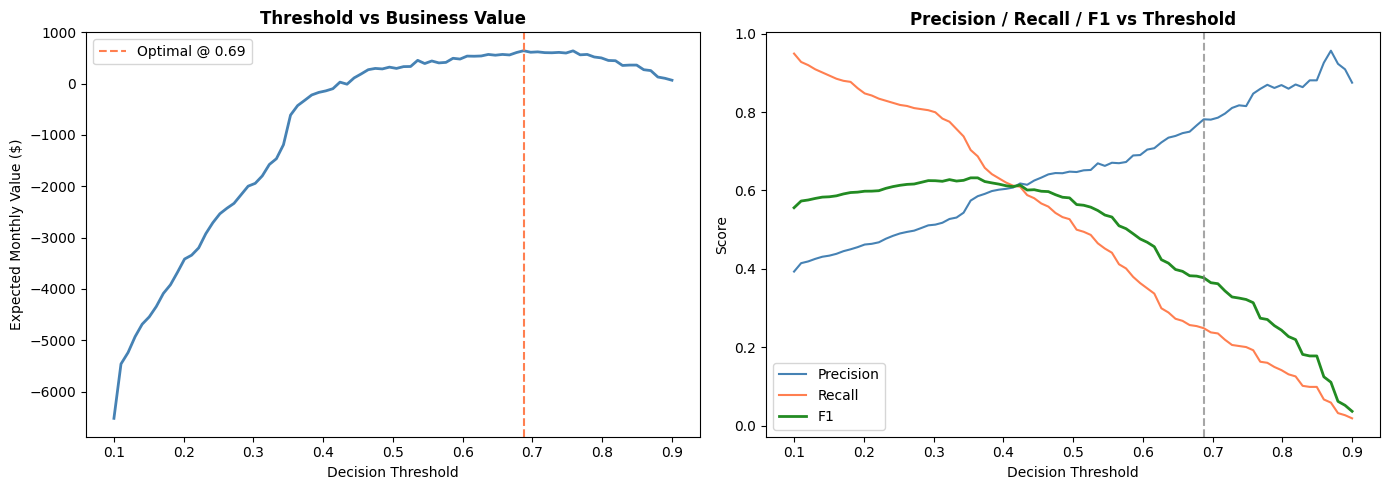

In [20]:
MONTHLY_REVENUE   = 65    # avg monthly charge ($)
RETENTION_COST    = 20    # cost of retention offer ($)
RETENTION_SUCCESS = 0.5   # fraction of intervened churners saved

y_proba = calibrated_model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.1, 0.9, 80)
ev_scores, precision_list, recall_list, f1_list = [], [], [], []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    tp = ((y_pred==1) & (y_test==1)).sum()
    fp = ((y_pred==1) & (y_test==0)).sum()
    fn = ((y_pred==0) & (y_test==1)).sum()
    revenue_saved = tp * MONTHLY_REVENUE * RETENTION_SUCCESS
    cost_spent    = (tp + fp) * RETENTION_COST
    ev_scores.append(revenue_saved - cost_spent)
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    precision_list.append(prec); recall_list.append(rec); f1_list.append(f1)

best_threshold = thresholds[np.argmax(ev_scores)]
print(f"Optimal threshold : {best_threshold:.2f}")
print(f"Max expected value: ${max(ev_scores):,.0f} / month")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresholds, ev_scores, color="steelblue", linewidth=2)
axes[0].axvline(best_threshold, color="coral", linestyle="--", label=f"Optimal @ {best_threshold:.2f}")
axes[0].set_xlabel("Decision Threshold"); axes[0].set_ylabel("Expected Monthly Value ($)")
axes[0].set_title("Threshold vs Business Value", fontweight="bold"); axes[0].legend()

axes[1].plot(thresholds, precision_list, label="Precision", color="steelblue")
axes[1].plot(thresholds, recall_list,    label="Recall",    color="coral")
axes[1].plot(thresholds, f1_list,        label="F1",        color="forestgreen", linewidth=2)
axes[1].axvline(best_threshold, color="grey", linestyle="--", alpha=0.7)
axes[1].set_xlabel("Decision Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("Precision / Recall / F1 vs Threshold", fontweight="bold"); axes[1].legend()
plt.tight_layout(); plt.show()

## 9. SHAP Explainability

In [21]:
# Extract base estimator from calibrated model for SHAP
base_estimator = calibrated_model.calibrated_classifiers_[0].estimator
explainer   = shap.TreeExplainer(base_estimator)
shap_values = explainer.shap_values(X_test)
print(f"SHAP values shape: {np.array(shap_values).shape}")

SHAP values shape: (1407, 32)


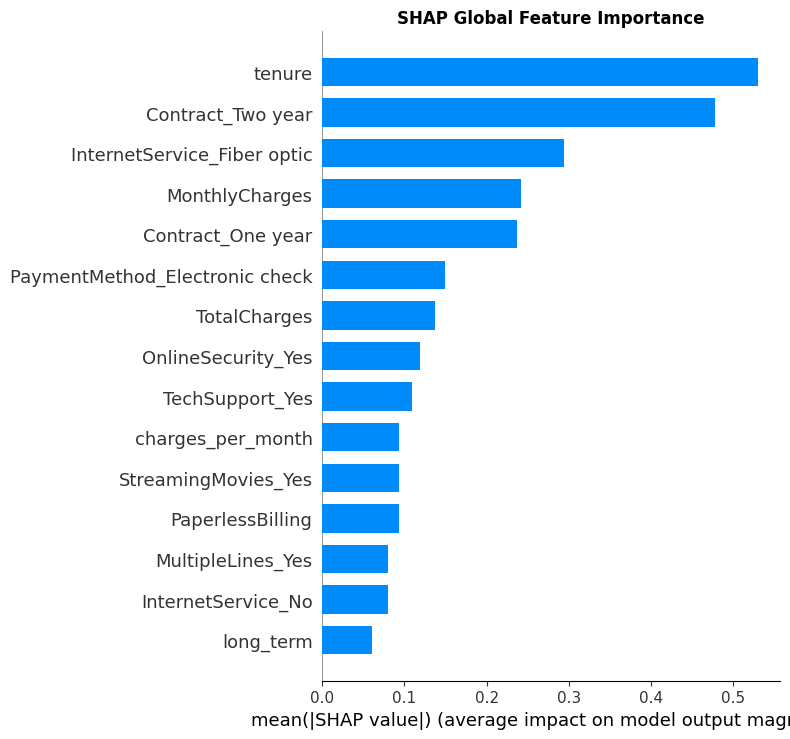

In [22]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.title("SHAP Global Feature Importance", fontweight="bold")
plt.tight_layout(); plt.show()

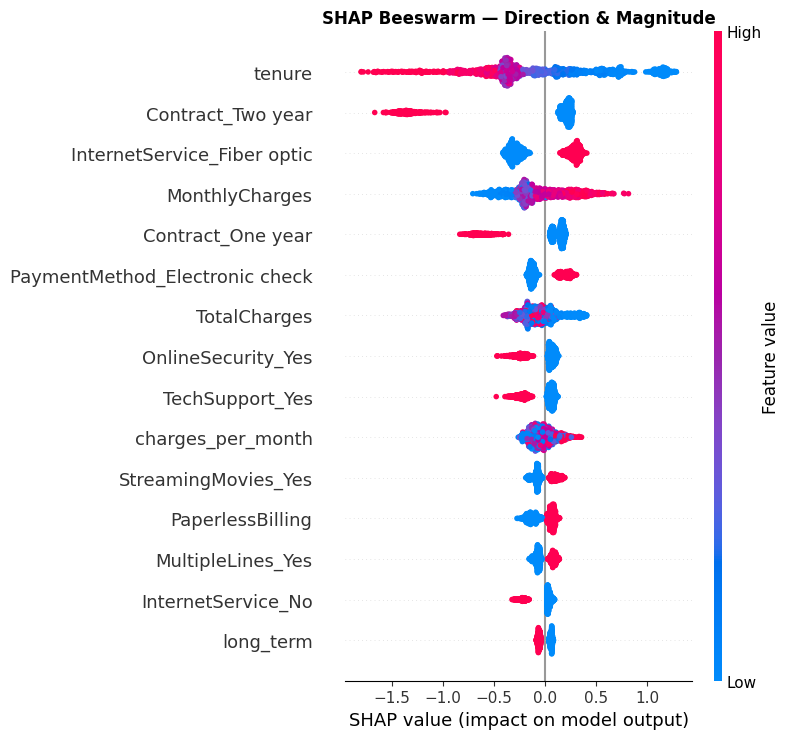

In [23]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("SHAP Beeswarm — Direction & Magnitude", fontweight="bold")
plt.tight_layout(); plt.show()

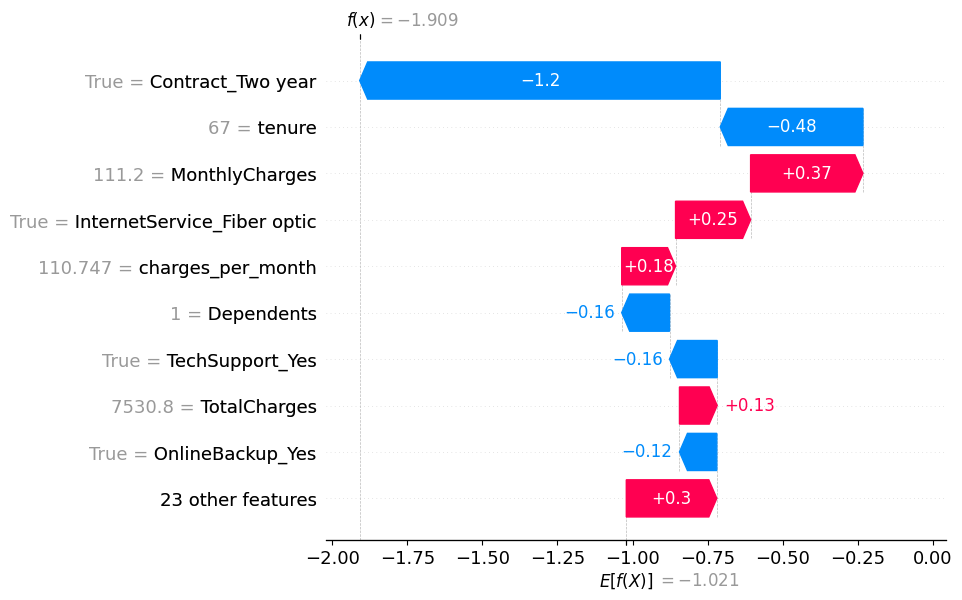

In [24]:
customer_idx = 42
shap.plots.waterfall(
    shap.Explanation(
        values        = shap_values[customer_idx],
        base_values   = explainer.expected_value,
        data          = X_test.iloc[customer_idx],
        feature_names = X_test.columns.tolist()
    )
)

In [25]:
def explain_customer(idx, shap_vals, feature_names, top_n=3):
    contributions = pd.Series(shap_vals[idx], index=feature_names)
    top_factors   = contributions.abs().nlargest(top_n)
    risk_score    = calibrated_model.predict_proba(X_test.iloc[[idx]])[0, 1]
    print(f"Customer #{idx}  |  Churn risk: {risk_score:.0%}\n")
    print("Top risk drivers:")
    for feat in top_factors.index:
        direction = "increases" if contributions[feat] > 0 else "decreases"
        val = X_test.iloc[idx][feat]
        print(f"  - {feat} = {val:.3f}  ->  {direction} churn risk  (SHAP: {contributions[feat]:+.3f})")
    print()

explain_customer(42, shap_values, X_test.columns.tolist())
explain_customer(10, shap_values, X_test.columns.tolist())

Customer #42  |  Churn risk: 14%

Top risk drivers:
  - Contract_Two year = 1.000  ->  decreases churn risk  (SHAP: -1.201)
  - tenure = 67.000  ->  decreases churn risk  (SHAP: -0.475)
  - MonthlyCharges = 111.200  ->  increases churn risk  (SHAP: +0.374)

Customer #10  |  Churn risk: 61%

Top risk drivers:
  - tenure = 4.000  ->  increases churn risk  (SHAP: +0.536)
  - InternetService_Fiber optic = 1.000  ->  increases churn risk  (SHAP: +0.265)
  - Contract_Two year = 0.000  ->  increases churn risk  (SHAP: +0.234)



## 10. Final Output: At-Risk Customer Priority List

In [26]:
y_proba = calibrated_model.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()
risk_df["churn_probability"] = y_proba
risk_df["predicted_churn"]   = (y_proba >= best_threshold).astype(int)
risk_df["monthly_revenue"]   = df.loc[X_test.index, "MonthlyCharges"]
risk_df["revenue_at_risk"]   = risk_df["churn_probability"] * risk_df["monthly_revenue"]

priority_list = (
    risk_df[risk_df["predicted_churn"] == 1]
    .sort_values("revenue_at_risk", ascending=False)
    [["churn_probability","monthly_revenue","revenue_at_risk"]]
)

print(f"Customers to contact  : {len(priority_list)}")
print(f"Total revenue at risk : ${priority_list['revenue_at_risk'].sum():,.0f}/month")
print(f"Avg churn probability : {priority_list['churn_probability'].mean():.1%}")

priority_list.head(10).style.format({
    "churn_probability": "{:.1%}",
    "monthly_revenue"  : "${:.2f}",
    "revenue_at_risk"  : "${:.2f}"
}).background_gradient(subset="revenue_at_risk", cmap="Reds")

Customers to contact  : 119
Total revenue at risk : $7,646/month
Avg churn probability : 80.5%


,churn_probability,monthly_revenue,revenue_at_risk
2631,97.1%,$99.25,$96.35
3380,100.0%,$95.10,$95.10
2797,92.8%,$100.95,$93.67
6839,87.6%,$100.75,$88.26
3727,91.1%,$96.60,$88.03
3085,82.8%,$105.35,$87.22
3956,82.8%,$105.30,$87.18
3159,91.1%,$94.85,$86.44
6240,92.6%,$93.30,$86.36
2753,89.0%,$95.65,$85.11
